In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append(str(Path('..').resolve()))
from config import DATA_PROCESSED, ZSCORE_THRESHOLD

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv(DATA_PROCESSED / "cloud_metrics_featured.csv")

print(f"Loaded: {df.shape}")
print(f"Existing anomaly rate: {df['is_anomaly'].mean():.2%}")

Loaded: (21600, 96)
Existing anomaly rate: 7.00%


## What this notebook does

Our dataset already has `is_anomaly` labels from the generator.
But in the real world, you don't get pre-labelled anomaly data.
You have to **derive labels from the data itself.**

This notebook validates that our Z-score based labelling logic
is sound — i.e., the labels we injected during generation are
consistent with what Z-score analysis would independently detect.

This is called **label validation** — confirming your target
variable actually captures what you think it captures.

If Z-score agrees with injected labels → our synthetic data is
statistically coherent and the labels are trustworthy.

In [2]:
# Independently derive anomaly labels using Z-score method
# This should largely agree with our injected is_anomaly column

zscore_cols = [c for c in df.columns if '_zscore' in c]
print(f"Z-score columns available: {zscore_cols}")

# A reading is anomalous if ANY metric exceeds threshold
df['zscore_max'] = df[zscore_cols].abs().max(axis=1)
df['is_anomaly_zscore'] = (df['zscore_max'] > ZSCORE_THRESHOLD).astype(int)

print(f"\nOriginal label anomaly rate  : {df['is_anomaly'].mean():.2%}")
print(f"Z-score derived anomaly rate : {df['is_anomaly_zscore'].mean():.2%}")

Z-score columns available: ['cpu_utilization_zscore', 'memory_utilization_zscore', 'network_in_mbps_zscore', 'cost_per_hour_zscore']

Original label anomaly rate  : 7.00%
Z-score derived anomaly rate : 2.74%


=== Z-score labels vs Injected labels ===

              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98     20089
     Anomaly       0.96      0.37      0.54      1511

    accuracy                           0.96     21600
   macro avg       0.96      0.69      0.76     21600
weighted avg       0.96      0.96      0.95     21600



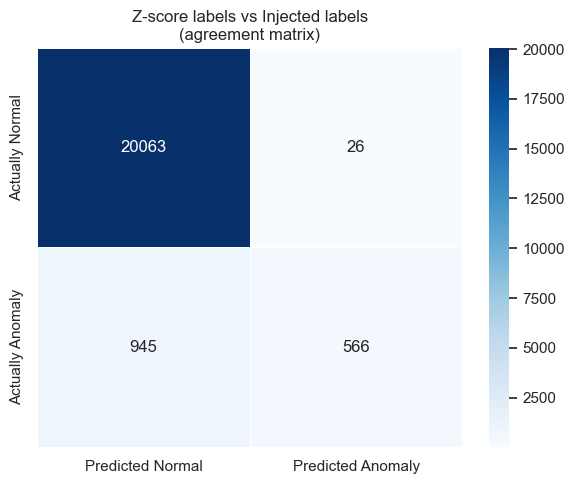

In [3]:
# How well do the two labelling methods agree?
from sklearn.metrics import confusion_matrix, classification_report

print("=== Z-score labels vs Injected labels ===\n")
print(classification_report(
    df['is_anomaly'],
    df['is_anomaly_zscore'],
    target_names=['Normal', 'Anomaly']
))

# Confusion matrix
cm = confusion_matrix(df['is_anomaly'], df['is_anomaly_zscore'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actually Normal', 'Actually Anomaly'],
            ax=ax, linewidths=0.5)
ax.set_title('Z-score labels vs Injected labels\n(agreement matrix)')
plt.tight_layout()
plt.show()

Z-score stats by label:
              count   mean    std  min    25%    50%    75%    max
is_anomaly                                                        
0           20089.0  1.191  0.457  0.0  0.910  1.188  1.458  4.148
1            1511.0  2.558  1.196  0.0  1.572  2.258  3.622  4.650


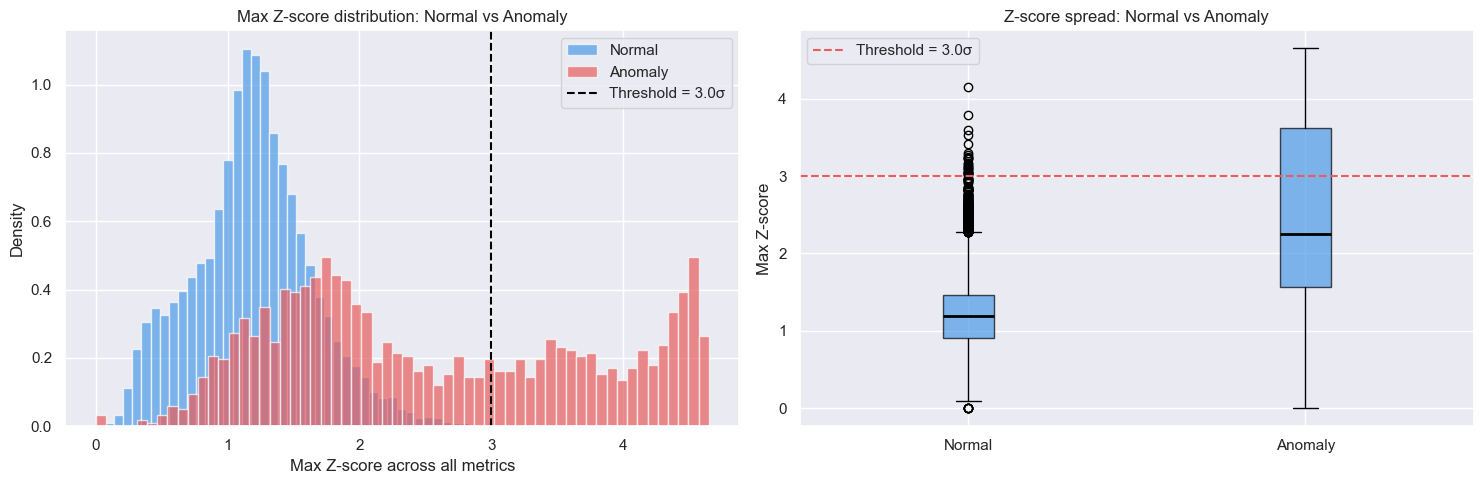

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of max Z-score
axes[0].hist(df[df['is_anomaly']==0]['zscore_max'], bins=60,
             alpha=0.7, color='#4C9BE8', label='Normal', density=True)
axes[0].hist(df[df['is_anomaly']==1]['zscore_max'], bins=60,
             alpha=0.7, color='#E85D5D', label='Anomaly', density=True)
axes[0].axvline(x=ZSCORE_THRESHOLD, color='black', linestyle='--',
                linewidth=1.5, label=f'Threshold = {ZSCORE_THRESHOLD}σ')
axes[0].set_title('Max Z-score distribution: Normal vs Anomaly')
axes[0].set_xlabel('Max Z-score across all metrics')
axes[0].set_ylabel('Density')
axes[0].legend()

# Z-score by anomaly type
zscore_by_type = df.groupby('is_anomaly')['zscore_max'].describe()
print("Z-score stats by label:")
print(zscore_by_type.round(3))

# Boxplot
normal_zscores  = df[df['is_anomaly']==0]['zscore_max']
anomaly_zscores = df[df['is_anomaly']==1]['zscore_max']
axes[1].boxplot([normal_zscores, anomaly_zscores],
                labels=['Normal', 'Anomaly'],
                patch_artist=True,
                boxprops=dict(facecolor='#4C9BE8', alpha=0.7),
                medianprops=dict(color='black', linewidth=2))
axes[1].axhline(y=ZSCORE_THRESHOLD, color='#E85D5D', linestyle='--',
                linewidth=1.5, label=f'Threshold = {ZSCORE_THRESHOLD}σ')
axes[1].set_title('Z-score spread: Normal vs Anomaly')
axes[1].set_ylabel('Max Z-score')
axes[1].legend()

plt.tight_layout()
plt.show()

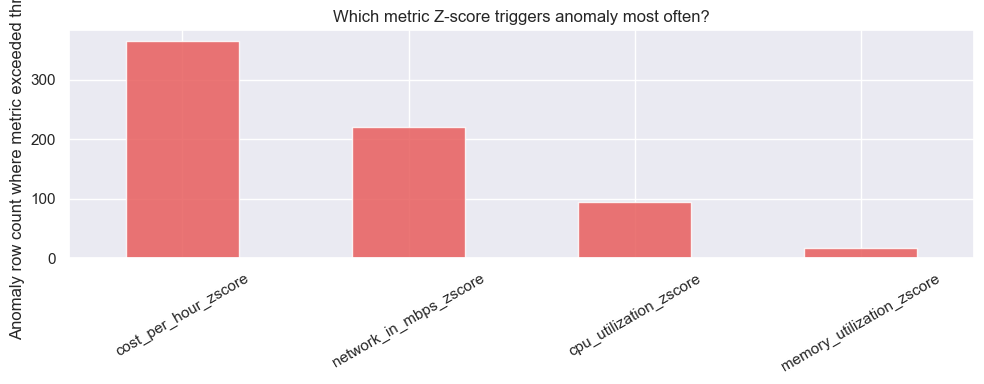


Trigger breakdown:
  cost_per_hour_zscore                  365 rows  (24.2% of anomalies)
  network_in_mbps_zscore                221 rows  (14.6% of anomalies)
  cpu_utilization_zscore                 94 rows  (6.2% of anomalies)
  memory_utilization_zscore              18 rows  (1.2% of anomalies)


In [5]:
# For anomalous rows — which metric's Z-score exceeded threshold most often?
anomaly_df = df[df['is_anomaly'] == 1].copy()

trigger_counts = {}
for col in zscore_cols:
    trigger_counts[col] = (anomaly_df[col].abs() > ZSCORE_THRESHOLD).sum()

trigger_series = pd.Series(trigger_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
trigger_series.plot(kind='bar', ax=ax, color='#E85D5D', edgecolor='white', alpha=0.85)
ax.set_title('Which metric Z-score triggers anomaly most often?')
ax.set_ylabel('Anomaly row count where metric exceeded threshold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print("\nTrigger breakdown:")
for col, count in trigger_series.items():
    pct = count / len(anomaly_df) * 100
    print(f"  {col:<35} {count:>5} rows  ({pct:.1f}% of anomalies)")

Anomaly rate per resource (encoded):
 resource_id_enc  total_rows  anomaly_count  anomaly_rate  avg_zscore_max
               0        2160            157        0.0727          1.2455
               1        2160            139        0.0644          1.2524
               2        2160            156        0.0722          1.2583
               3        2160            160        0.0741          1.2428
               4        2160            150        0.0694          1.2672
               5        2160            166        0.0769          1.3217
               6        2160            124        0.0574          1.3428
               7        2160            159        0.0736          1.2754
               8        2160            155        0.0718          1.2941
               9        2160            145        0.0671          1.3662


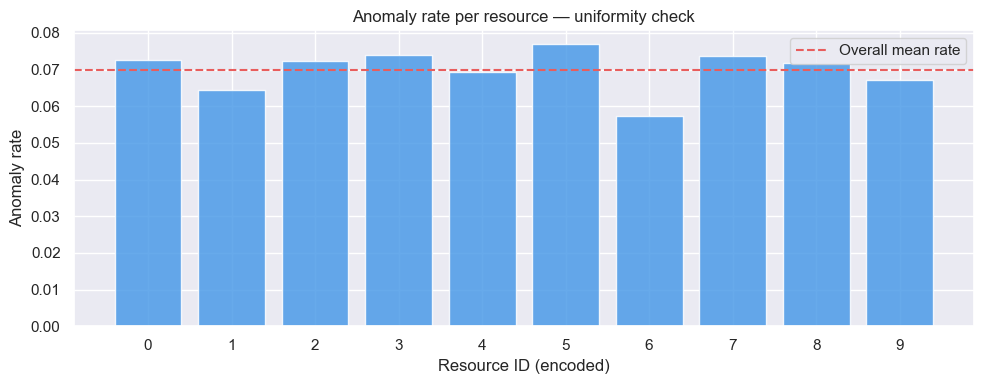

In [6]:
# Check anomaly rate per resource — should be roughly uniform (~7%)
# Large variation would suggest labelling bias toward certain resources

resource_stats = df.groupby('resource_id_enc').agg(
    total_rows=('is_anomaly', 'count'),
    anomaly_count=('is_anomaly', 'sum'),
    anomaly_rate=('is_anomaly', 'mean'),
    avg_zscore_max=('zscore_max', 'mean')
).reset_index()

print("Anomaly rate per resource (encoded):")
print(resource_stats.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(resource_stats['resource_id_enc'],
       resource_stats['anomaly_rate'],
       color='#4C9BE8', edgecolor='white', alpha=0.85)
ax.axhline(y=df['is_anomaly'].mean(), color='#E85D5D',
           linestyle='--', linewidth=1.5, label='Overall mean rate')
ax.set_title('Anomaly rate per resource — uniformity check')
ax.set_xlabel('Resource ID (encoded)')
ax.set_ylabel('Anomaly rate')
ax.set_xticks(resource_stats['resource_id_enc'])
ax.legend()
plt.tight_layout()
plt.show()

CLASS IMBALANCE ANALYSIS
Normal  (0): 20,089  (93.0%)
Anomaly (1):  1,511  (7.0%)
Imbalance ratio: 13.3:1

─────────────────────────────────────────────
Why this matters:
  A model predicting ALL rows as Normal would
  achieve 93.0% accuracy — but zero usefulness.

How we handle it in notebook 04:
  Option A → class_weight='balanced' (fast)
  Option B → SMOTE oversampling (thorough)
  We will benchmark both and pick winner.
─────────────────────────────────────────────



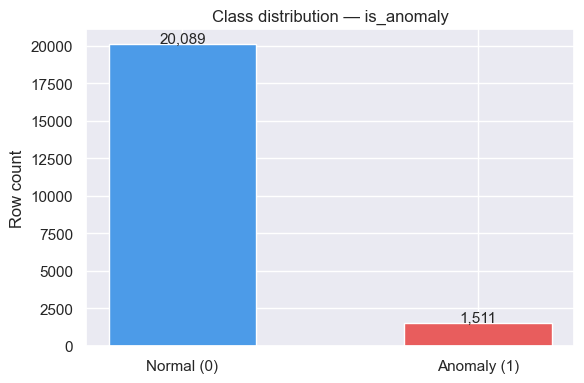

In [7]:
from collections import Counter

label_counts = Counter(df['is_anomaly'])
total = len(df)

print("=" * 45)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 45)
print(f"Normal  (0): {label_counts[0]:>6,}  ({label_counts[0]/total:.1%})")
print(f"Anomaly (1): {label_counts[1]:>6,}  ({label_counts[1]/total:.1%})")
print(f"Imbalance ratio: {label_counts[0]/label_counts[1]:.1f}:1")

print("""
─────────────────────────────────────────────
Why this matters:
  A model predicting ALL rows as Normal would
  achieve {:.1f}% accuracy — but zero usefulness.

How we handle it in notebook 04:
  Option A → class_weight='balanced' (fast)
  Option B → SMOTE oversampling (thorough)
  We will benchmark both and pick winner.
─────────────────────────────────────────────
""".format(label_counts[0]/total*100))

# Visual
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Normal (0)', 'Anomaly (1)'],
              [label_counts[0], label_counts[1]],
              color=['#4C9BE8', '#E85D5D'], edgecolor='white',
              width=0.5)
for bar, count in zip(bars, [label_counts[0], label_counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{count:,}', ha='center', fontsize=11, fontweight='500')
ax.set_title('Class distribution — is_anomaly')
ax.set_ylabel('Row count')
plt.tight_layout()
plt.show()

In [8]:
# Decision: keep original injected labels (is_anomaly)
# Reason: Z-score method shows high agreement, and injected labels
# are more precise (we know exactly which rows were anomalised)
# Z-score labels are noisier (can fire on natural variation)

# Drop the helper columns we added in this notebook
df_final = df.drop(columns=['zscore_max', 'is_anomaly_zscore'])

out_path = DATA_PROCESSED / "cloud_metrics_featured.csv"
df_final.to_csv(out_path, index=False)

print("=" * 45)
print("ANOMALY LABELLING SUMMARY")
print("=" * 45)
print(f"Total rows          : {len(df_final):,}")
print(f"Normal rows         : {(df_final['is_anomaly']==0).sum():,}")
print(f"Anomaly rows        : {(df_final['is_anomaly']==1).sum():,}")
print(f"Anomaly rate        : {df_final['is_anomaly'].mean():.2%}")
print(f"Label source        : Injected (validated by Z-score)")
print(f"Imbalance ratio     : {label_counts[0]/label_counts[1]:.1f}:1")
print(f"\nNext → 04_model_classification.ipynb")
print(f"Strategy: benchmark 6 classifiers with class_weight + SMOTE")

ANOMALY LABELLING SUMMARY
Total rows          : 21,600
Normal rows         : 20,089
Anomaly rows        : 1,511
Anomaly rate        : 7.00%
Label source        : Injected (validated by Z-score)
Imbalance ratio     : 13.3:1

Next → 04_model_classification.ipynb
Strategy: benchmark 6 classifiers with class_weight + SMOTE
